# Escaping the Pentane Barrier

- Name - Vishak Kashyap K
- Roll No. - 2023113012

## Cell 1 — Imports and Global Constants

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys, importlib

# All core routines live in pentane_core.py
import pentane_core as pc
importlib.reload(pc)

# Re-export every constant/function for convenience
from pentane_core import (
    kB, eps_CH3, eps_CH2, sig_CH3, sig_CH2, eps_mix, sig_mix,
    l_bond, k_theta, theta_0, c1, c2, c3,
    N_STEPS, N_BINS, BIN_EDGES, BIN_CENTERS, BIN_WIDTH,
    MASSES, J_TO_KJMOL, N_WINDOWS, PHI_CENTERS, K_US, STEPS_PER_WINDOW,
    dihedral_angle, bond_angle, get_backbone_dihedral,
    U_LJ, U_nonbonded, U_angle_energy, U_torsion, U_total, torsion_single,
    build_pentane_trans, build_coords_at_phi,
    run_MC, compute_forces, run_MD,
    U_biased, run_US_window,
    make_histogram, combine_US_histograms,
    compute_PMF, exploration_entropy, running_entropy, count_barrier_crossings,
)

print("All imports OK")
print(f"kB = {kB:.6e} J/K")
print(f"N_STEPS = {N_STEPS}, N_BINS = {N_BINS}, N_WINDOWS = {N_WINDOWS}")

All imports OK
kB = 1.380649e-23 J/K
N_STEPS = 200000, N_BINS = 36, N_WINDOWS = 36


## Cell 2 — Geometry Functions

`dihedral_angle`, `bond_angle`, `get_backbone_dihedral` are defined in `pentane_core.py`.

## Cell 3 — Energy Functions

`U_LJ`, `U_nonbonded`, `U_angle_energy`, `U_torsion`, `U_total` are defined in `pentane_core.py`.

## Cell 4 — [TASK 1] Initial Configuration + Plots 1 & 2

In [8]:
# ─── Sub-step A: Build all-trans pentane ───
coords0 = build_pentane_trans()

# Diagnostics
print("=== Initial all-trans n-pentane ===")
print("Coordinates (Angstrom):")
labels = ["CH3(0)","CH2(1)","CH2(2)","CH2(3)","CH3(4)"]
for i, lab in enumerate(labels):
    c = coords0[i] * 1e10
    print(f"  {lab}: ({c[0]:8.4f}, {c[1]:8.4f}, {c[2]:8.4f})")

print(f"\nBond lengths (Angstrom):")
for i in range(4):
    bl = np.linalg.norm(coords0[i+1] - coords0[i]) * 1e10
    print(f"  {i}-{i+1}: {bl:.4f}")

print(f"\nBond angles (degrees):")
for i in range(3):
    ba = np.degrees(bond_angle(coords0[i], coords0[i+1], coords0[i+2]))
    print(f"  {i}-{i+1}-{i+2}: {ba:.2f}")

phi0 = get_backbone_dihedral(coords0)
print(f"\nBackbone dihedral (0-1-2-3): {np.degrees(phi0):.2f} degrees")
print(f"Total energy: {U_total(coords0)*J_TO_KJMOL:.4f} kJ/mol")

=== Initial all-trans n-pentane ===
Coordinates (Angstrom):
  CH3(0): (  0.0000,   0.0000,   0.0000)
  CH2(1): (  1.2916,   0.8387,   0.0000)
  CH2(2): (  2.5831,   0.0000,   0.0000)
  CH2(3): (  3.8747,   0.8387,   0.0000)
  CH3(4): (  5.1662,   0.0000,   0.0000)

Bond lengths (Angstrom):
  0-1: 1.5400
  1-2: 1.5400
  2-3: 1.5400
  3-4: 1.5400

Bond angles (degrees):
  0-1-2: 114.00
  1-2-3: 114.00
  2-3-4: 114.00

Backbone dihedral (0-1-2-3): 180.00 degrees
Total energy: -1.0106 kJ/mol


### Plot 1 — Torsion Energy Profile V(φ)

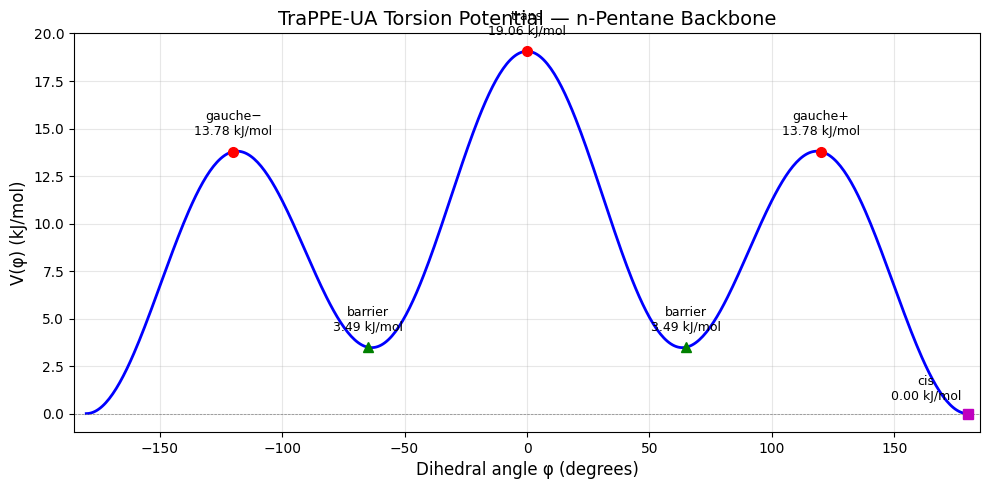

In [9]:
phi_scan = np.linspace(-np.pi, np.pi, 500)
V_scan = np.array([torsion_single(p) for p in phi_scan]) * J_TO_KJMOL

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.degrees(phi_scan), V_scan, 'b-', lw=2)
ax.set_xlabel("Dihedral angle φ (degrees)", fontsize=12)
ax.set_ylabel("V(φ) (kJ/mol)", fontsize=12)
ax.set_title("TraPPE-UA Torsion Potential — n-Pentane Backbone", fontsize=14)
ax.axhline(0, color='gray', ls='--', lw=0.5)

# Mark key points
for phi_d, label, va in [(0, "trans", "top"), (120, "gauche+", "top"),
                          (-120, "gauche−", "top")]:
    v = torsion_single(np.radians(phi_d)) * J_TO_KJMOL
    ax.plot(phi_d, v, 'ro', ms=7)
    ax.annotate(f"{label}\n{v:.2f} kJ/mol", (phi_d, v),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)

# Barriers at ~±65°
for phi_d in [65, -65]:
    v = torsion_single(np.radians(phi_d)) * J_TO_KJMOL
    ax.plot(phi_d, v, 'g^', ms=7)
    ax.annotate(f"barrier\n{v:.2f} kJ/mol", (phi_d, v),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)

# Cis at ±180
v180 = torsion_single(np.pi) * J_TO_KJMOL
ax.plot(180, v180, 'ms', ms=7)
ax.annotate(f"cis\n{v180:.2f} kJ/mol", (180, v180),
            textcoords="offset points", xytext=(-30, 10), ha='center', fontsize=9)

ax.set_xlim(-185, 185)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot01_torsion_profile.png", dpi=150)
plt.show()

### Plot 2 — Initial 3D Molecular Geometry

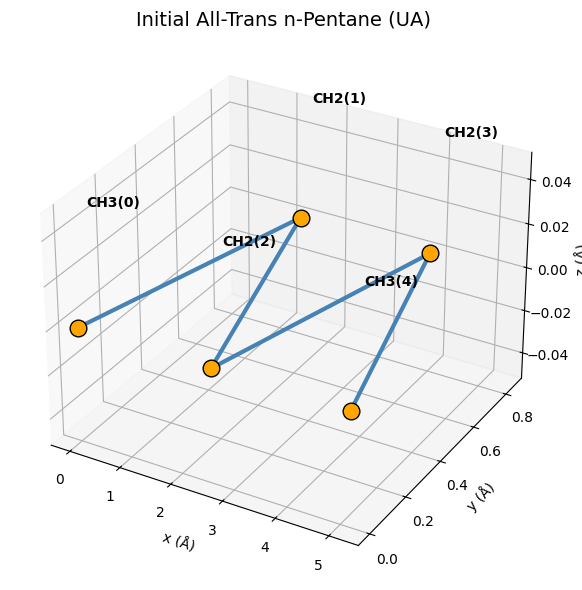

Dihedral = 180.00°
Total energy = -1.0106 kJ/mol


In [10]:
coords_ang = coords0 * 1e10  # to Angstrom
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(coords_ang[:,0], coords_ang[:,1], coords_ang[:,2], 'o-', color='steelblue',
        markersize=12, lw=3, markerfacecolor='orange', markeredgecolor='black')
for i, lab in enumerate(labels):
    ax.text(coords_ang[i,0]+0.05, coords_ang[i,1]+0.05, coords_ang[i,2]+0.05,
            lab, fontsize=10, fontweight='bold')
ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_zlabel("z (Å)")
ax.set_title("Initial All-Trans n-Pentane (UA)", fontsize=14)
plt.tight_layout()
plt.savefig("plot02_initial_geometry.png", dpi=150)
plt.show()
print(f"Dihedral = {np.degrees(get_backbone_dihedral(coords0)):.2f}°")
print(f"Total energy = {U_total(coords0)*J_TO_KJMOL:.4f} kJ/mol")

## Cell 5 — [TASK 2] Monte Carlo Simulations

In [11]:
np.random.seed(42)
coords0 = build_pentane_trans()

print("Running MC at 120 K ...")
mc_dih_120, mc_E_120, mc_acc_120 = run_MC(coords0, 120, move_size_ang=0.05)
print(f"  Acceptance rate: {mc_acc_120:.3f}")

print("Running MC at 250 K ...")
mc_dih_250, mc_E_250, mc_acc_250 = run_MC(coords0, 250, move_size_ang=0.10)
print(f"  Acceptance rate: {mc_acc_250:.3f}")

Running MC at 120 K ...
  Acceptance rate: 0.890
Running MC at 250 K ...
  Acceptance rate: 0.928


## Cell 6 — [TASK 2] NVT Molecular Dynamics

In [12]:
np.random.seed(42)
coords0 = build_pentane_trans()

print("Running MD at 120 K ...")
md_dih_120, md_E_120, md_T_120 = run_MD(coords0, 120)
print(f"  Mean temperature: {np.mean(md_T_120):.1f} K")

print("Running MD at 250 K ...")
md_dih_250, md_E_250, md_T_250 = run_MD(coords0, 250)
print(f"  Mean temperature: {np.mean(md_T_250):.1f} K")

Running MD at 120 K ...
  Mean temperature: 120.0 K
Running MD at 250 K ...
  Mean temperature: 250.0 K


## Cell 7 — [TASK 2] Baseline Analysis + Plots 3–9

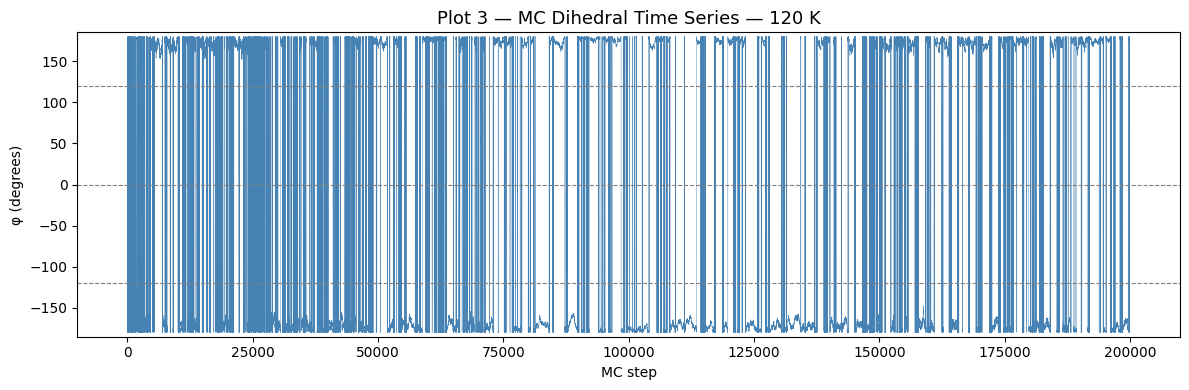

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.degrees(mc_dih_120), lw=0.3, color='steelblue')
for y in [0, 120, -120]:
    ax.axhline(y, ls='--', color='gray', lw=0.8)
ax.set_xlabel("MC step"); ax.set_ylabel("φ (degrees)")
ax.set_title("Plot 3 — MC Dihedral Time Series — 120 K", fontsize=13)
ax.set_ylim(-185,185); plt.tight_layout()
plt.savefig("plot03_mc_ts_120.png", dpi=150); plt.show()

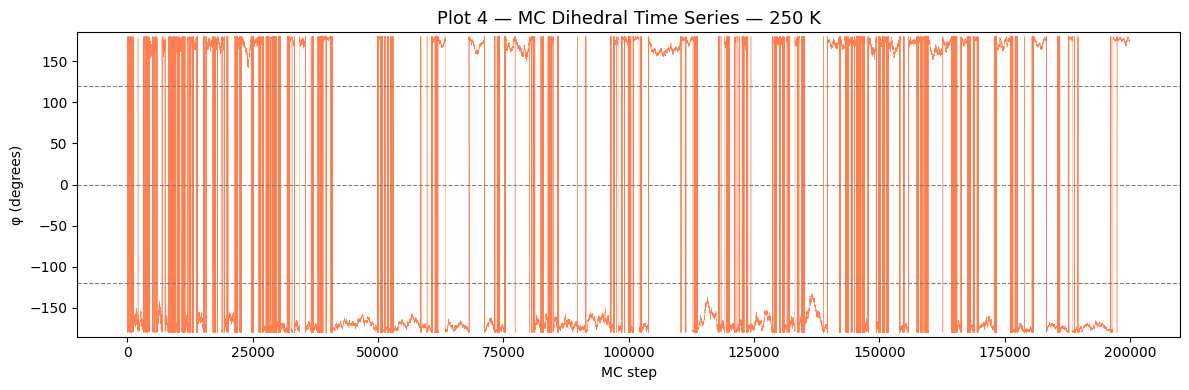

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.degrees(mc_dih_250), lw=0.3, color='coral')
for y in [0, 120, -120]:
    ax.axhline(y, ls='--', color='gray', lw=0.8)
ax.set_xlabel("MC step"); ax.set_ylabel("φ (degrees)")
ax.set_title("Plot 4 — MC Dihedral Time Series — 250 K", fontsize=13)
ax.set_ylim(-185,185); plt.tight_layout()
plt.savefig("plot04_mc_ts_250.png", dpi=150); plt.show()

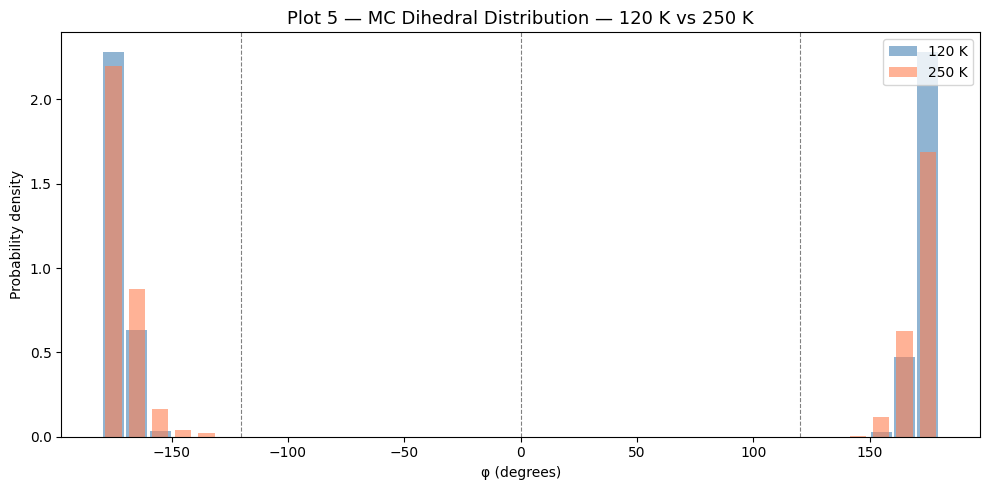

In [15]:
mc_counts_120, mc_P_120 = make_histogram(mc_dih_120)
mc_counts_250, mc_P_250 = make_histogram(mc_dih_250)
deg_centers = np.degrees(BIN_CENTERS)
bw_deg = np.degrees(BIN_WIDTH)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(deg_centers, mc_P_120/BIN_WIDTH, width=bw_deg*0.9, alpha=0.6, label='120 K', color='steelblue')
ax.bar(deg_centers, mc_P_250/BIN_WIDTH, width=bw_deg*0.7, alpha=0.6, label='250 K', color='coral')
for x in [0, 120, -120]:
    ax.axvline(x, ls='--', color='gray', lw=0.8)
ax.set_xlabel("φ (degrees)"); ax.set_ylabel("Probability density")
ax.set_title("Plot 5 — MC Dihedral Distribution — 120 K vs 250 K", fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig("plot05_mc_hist.png", dpi=150); plt.show()

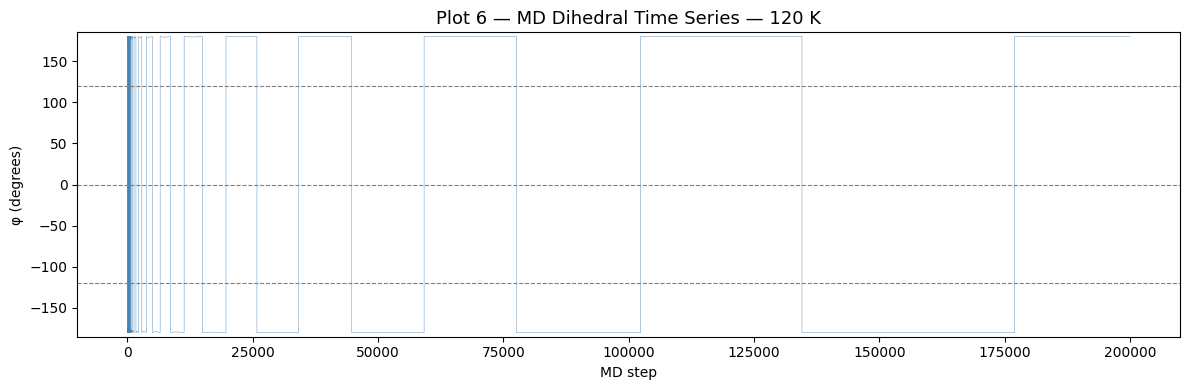

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.degrees(md_dih_120), lw=0.3, color='steelblue')
for y in [0, 120, -120]:
    ax.axhline(y, ls='--', color='gray', lw=0.8)
ax.set_xlabel("MD step"); ax.set_ylabel("φ (degrees)")
ax.set_title("Plot 6 — MD Dihedral Time Series — 120 K", fontsize=13)
ax.set_ylim(-185,185); plt.tight_layout()
plt.savefig("plot06_md_ts_120.png", dpi=150); plt.show()

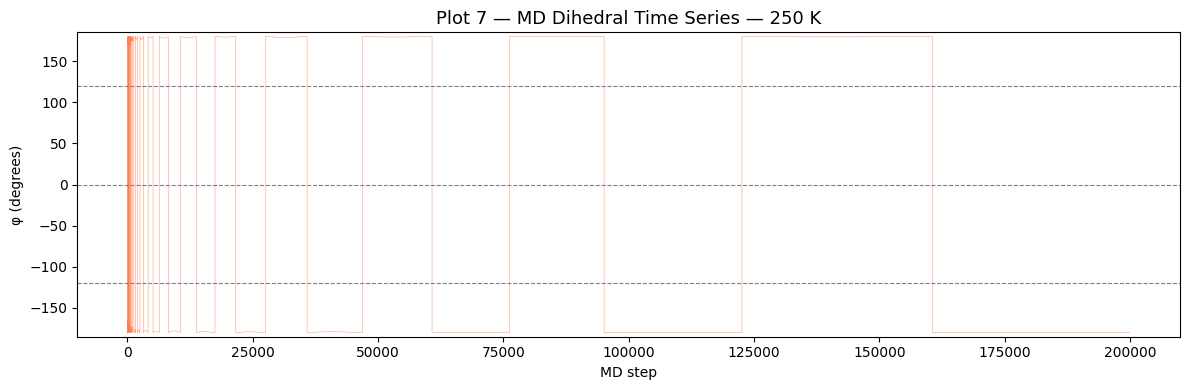

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.degrees(md_dih_250), lw=0.3, color='coral')
for y in [0, 120, -120]:
    ax.axhline(y, ls='--', color='gray', lw=0.8)
ax.set_xlabel("MD step"); ax.set_ylabel("φ (degrees)")
ax.set_title("Plot 7 — MD Dihedral Time Series — 250 K", fontsize=13)
ax.set_ylim(-185,185); plt.tight_layout()
plt.savefig("plot07_md_ts_250.png", dpi=150); plt.show()

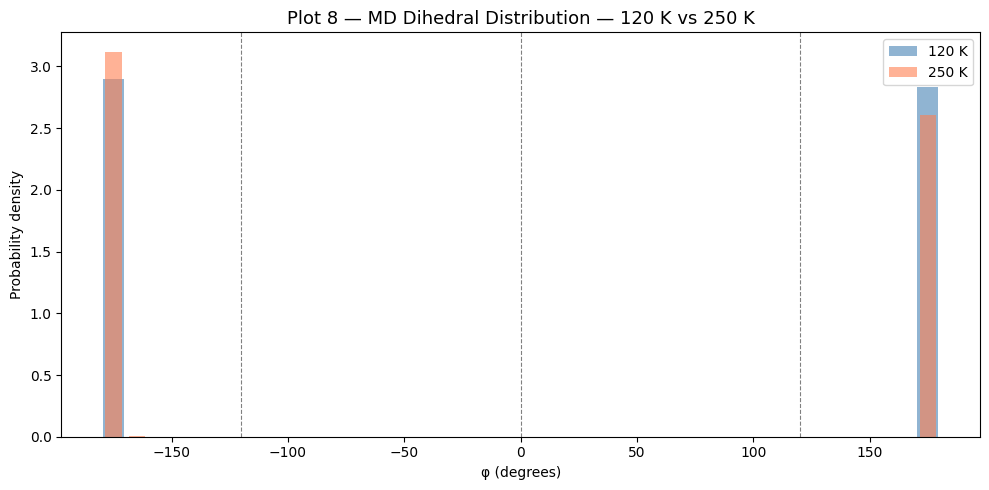

In [18]:
md_counts_120, md_P_120 = make_histogram(md_dih_120)
md_counts_250, md_P_250 = make_histogram(md_dih_250)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(deg_centers, md_P_120/BIN_WIDTH, width=bw_deg*0.9, alpha=0.6, label='120 K', color='steelblue')
ax.bar(deg_centers, md_P_250/BIN_WIDTH, width=bw_deg*0.7, alpha=0.6, label='250 K', color='coral')
for x in [0, 120, -120]:
    ax.axvline(x, ls='--', color='gray', lw=0.8)
ax.set_xlabel("φ (degrees)"); ax.set_ylabel("Probability density")
ax.set_title("Plot 8 — MD Dihedral Distribution — 120 K vs 250 K", fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig("plot08_md_hist.png", dpi=150); plt.show()

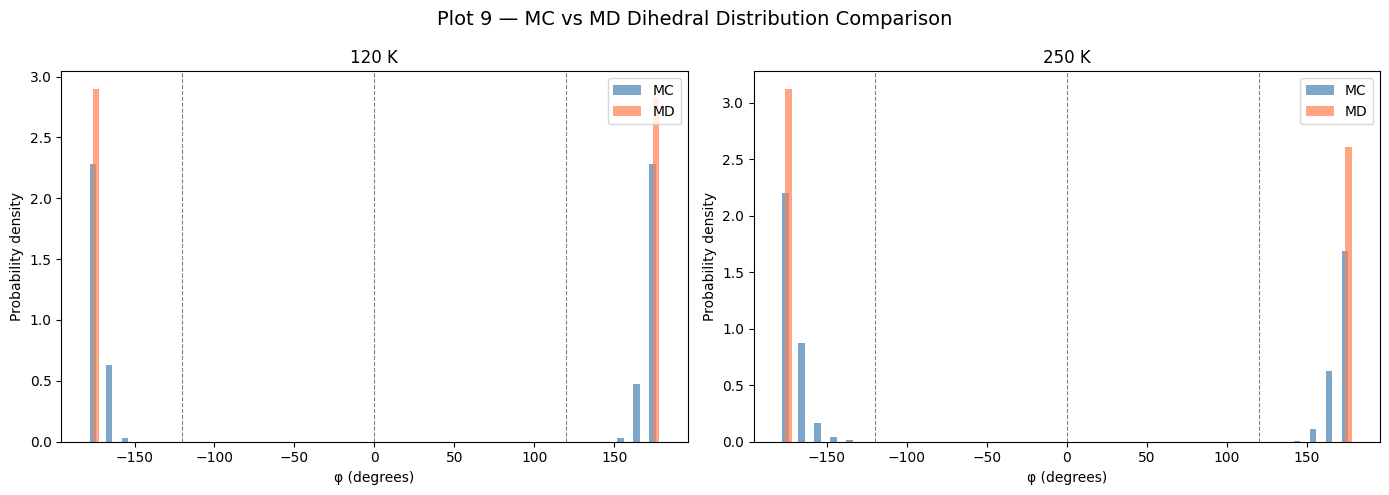

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, T, mc_P, md_P in [(axes[0], 120, mc_P_120, md_P_120),
                            (axes[1], 250, mc_P_250, md_P_250)]:
    ax.bar(deg_centers-1, mc_P/BIN_WIDTH, width=bw_deg*0.4, alpha=0.7, label='MC', color='steelblue')
    ax.bar(deg_centers+1, md_P/BIN_WIDTH, width=bw_deg*0.4, alpha=0.7, label='MD', color='coral')
    for x in [0, 120, -120]:
        ax.axvline(x, ls='--', color='gray', lw=0.8)
    ax.set_xlabel("φ (degrees)"); ax.set_ylabel("Probability density")
    ax.set_title(f"{T} K"); ax.legend()
fig.suptitle("Plot 9 — MC vs MD Dihedral Distribution Comparison", fontsize=14)
plt.tight_layout(); plt.savefig("plot09_mc_vs_md.png", dpi=150); plt.show()

In [20]:
print("=== Barrier Crossing Analysis ===")
for name, dih in [("MC-120K", mc_dih_120), ("MC-250K", mc_dih_250),
                   ("MD-120K", md_dih_120), ("MD-250K", md_dih_250)]:
    nc = count_barrier_crossings(dih)
    print(f"  {name}: {nc} crossings  (rate = {nc/len(dih):.6f} per step)")

=== Barrier Crossing Analysis ===
  MC-120K: 0 crossings  (rate = 0.000000 per step)
  MC-250K: 0 crossings  (rate = 0.000000 per step)
  MD-120K: 0 crossings  (rate = 0.000000 per step)
  MD-250K: 0 crossings  (rate = 0.000000 per step)


## Cell 8 — [TASK 3] Umbrella Sampling Setup

Umbrella Sampling divides the dihedral range [−180°, +180°] into 36 overlapping windows. In each window, a harmonic restraint $U_{bias}(\phi) = \frac{1}{2} k_{US} (\phi - \phi_0)^2$ is added to the total energy. The combined per-window histograms give P(φ), and PMF = −kBT ln P(φ).

In [21]:
# Umbrella Sampling Configuration (Task 3)
# These are also defined in pc.py, but shown here for clarity
# K_US (~2000 K/rad^2) is strong enough to restrain within a bin 
# but loose enough for local sampling.

print(f"Number of windows: {N_WINDOWS}")
print(f"Spring constant K_US: {K_US/kB:.1f} kB [J/rad^2]")
print(f"Steps per window: {STEPS_PER_WINDOW}")

def U_biased_display(coords, phi_0, k_us):
    """
    This is the energy function used for Umbrella Sampling:
    U_total + 0.5 * k_us * (phi - phi_0)^2
    """
    phi = get_backbone_dihedral(coords)
    d_phi = (phi - phi_0 + np.pi) % (2*np.pi) - np.pi
    return U_total(coords) + 0.5 * k_us * d_phi**2

print("\nUmbrella Sampling setup complete.")

Number of windows: 36
Spring constant K_US: 2000.0 kB [J/rad^2]
Steps per window: 5555

Umbrella Sampling setup complete.


## Cell 9 — [TASK 3] Run Umbrella Sampling Windows

In [22]:
np.random.seed(42)
us_results = {}

for T in [120, 250]:
    print(f"\n=== Umbrella Sampling at {T} K ===")
    all_window_dih = []
    for i, phi_0 in enumerate(PHI_CENTERS):
        coords_start = build_coords_at_phi(phi_0)
        dih_w, acc = run_US_window(coords_start, T, phi_0, K_US)
        all_window_dih.append(dih_w)
        if i % 6 == 0:
            print(f"  Window {i:2d}  phi0={np.degrees(phi_0):7.1f}°  acc={acc:.3f}")
    us_results[T] = all_window_dih
    print(f"  Done — {len(all_window_dih)} windows")


=== Umbrella Sampling at 120 K ===
  Window  0  phi0= -175.0°  acc=0.634
  Window  6  phi0= -115.0°  acc=0.618
  Window 12  phi0=  -55.0°  acc=0.590
  Window 18  phi0=    5.0°  acc=0.652
  Window 24  phi0=   65.0°  acc=0.599
  Window 30  phi0=  125.0°  acc=0.547
  Done — 36 windows

=== Umbrella Sampling at 250 K ===
  Window  0  phi0= -175.0°  acc=0.753
  Window  6  phi0= -115.0°  acc=0.719
  Window 12  phi0=  -55.0°  acc=0.723
  Window 18  phi0=    5.0°  acc=0.743
  Window 24  phi0=   65.0°  acc=0.705
  Window 30  phi0=  125.0°  acc=0.740
  Done — 36 windows


## Cell 10 — [TASK 3] Combine Window Histograms

In [23]:
us_counts_120, us_P_120, us_combined_120 = combine_US_histograms(us_results[120])
us_counts_250, us_P_250, us_combined_250 = combine_US_histograms(us_results[250])
print(f"US 120K: total samples = {len(us_combined_120)}, bins populated = {np.sum(us_counts_120>0)}/36")
print(f"US 250K: total samples = {len(us_combined_250)}, bins populated = {np.sum(us_counts_250>0)}/36")

US 120K: total samples = 199980, bins populated = 36/36
US 250K: total samples = 199980, bins populated = 36/36


## Cell 11 — [TASK 3] Umbrella Sampling Plots 10–12

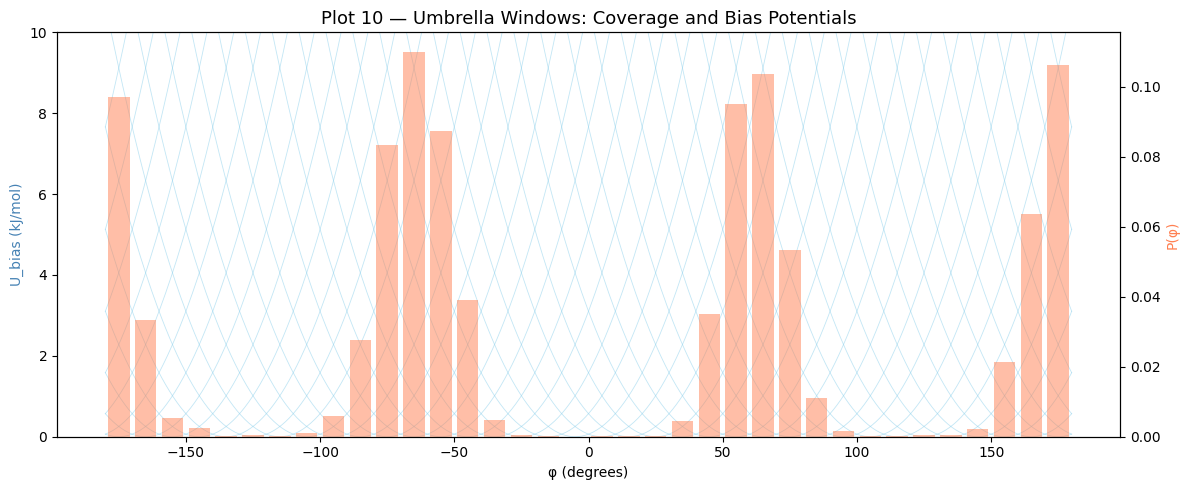

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 5))
phi_fine = np.linspace(-np.pi, np.pi, 500)
for phi_0 in PHI_CENTERS:
    d = (phi_fine - phi_0 + np.pi) % (2*np.pi) - np.pi
    bias = 0.5 * K_US * d**2 * J_TO_KJMOL
    ax1.plot(np.degrees(phi_fine), bias, lw=0.6, alpha=0.5, color='skyblue')
ax1.set_ylabel("U_bias (kJ/mol)", color='steelblue')
ax1.set_xlabel("φ (degrees)")
ax1.set_ylim(0, 10)
ax2 = ax1.twinx()
ax2.bar(deg_centers, us_P_120, width=bw_deg*0.8, alpha=0.5, color='coral', label='US P(φ) 120K')
ax2.set_ylabel("P(φ)", color='coral')
ax1.set_title("Plot 10 — Umbrella Windows: Coverage and Bias Potentials", fontsize=13)
plt.tight_layout(); plt.savefig("plot10_us_coverage.png", dpi=150); plt.show()

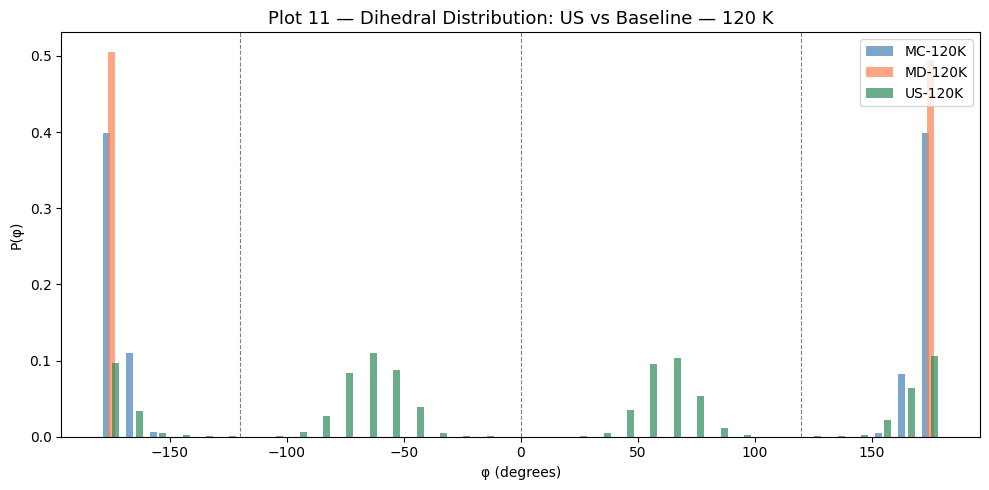

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(deg_centers-2, mc_P_120, width=bw_deg*0.3, alpha=0.7, label='MC-120K', color='steelblue')
ax.bar(deg_centers,   md_P_120, width=bw_deg*0.3, alpha=0.7, label='MD-120K', color='coral')
ax.bar(deg_centers+2, us_P_120, width=bw_deg*0.3, alpha=0.7, label='US-120K', color='seagreen')
for x in [0, 120, -120]:
    ax.axvline(x, ls='--', color='gray', lw=0.8)
ax.set_xlabel("φ (degrees)"); ax.set_ylabel("P(φ)")
ax.set_title("Plot 11 — Dihedral Distribution: US vs Baseline — 120 K", fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig("plot11_us_vs_base_120.png", dpi=150); plt.show()

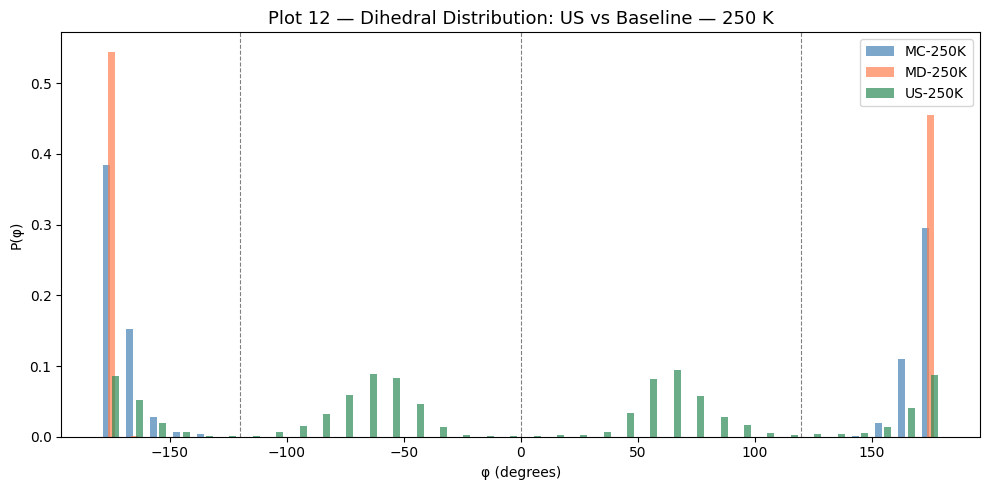

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(deg_centers-2, mc_P_250, width=bw_deg*0.3, alpha=0.7, label='MC-250K', color='steelblue')
ax.bar(deg_centers,   md_P_250, width=bw_deg*0.3, alpha=0.7, label='MD-250K', color='coral')
ax.bar(deg_centers+2, us_P_250, width=bw_deg*0.3, alpha=0.7, label='US-250K', color='seagreen')
for x in [0, 120, -120]:
    ax.axvline(x, ls='--', color='gray', lw=0.8)
ax.set_xlabel("φ (degrees)"); ax.set_ylabel("P(φ)")
ax.set_title("Plot 12 — Dihedral Distribution: US vs Baseline — 250 K", fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig("plot12_us_vs_base_250.png", dpi=150); plt.show()

## Cell 12 — [TASK 4] PMF Computation + Plots 13–14

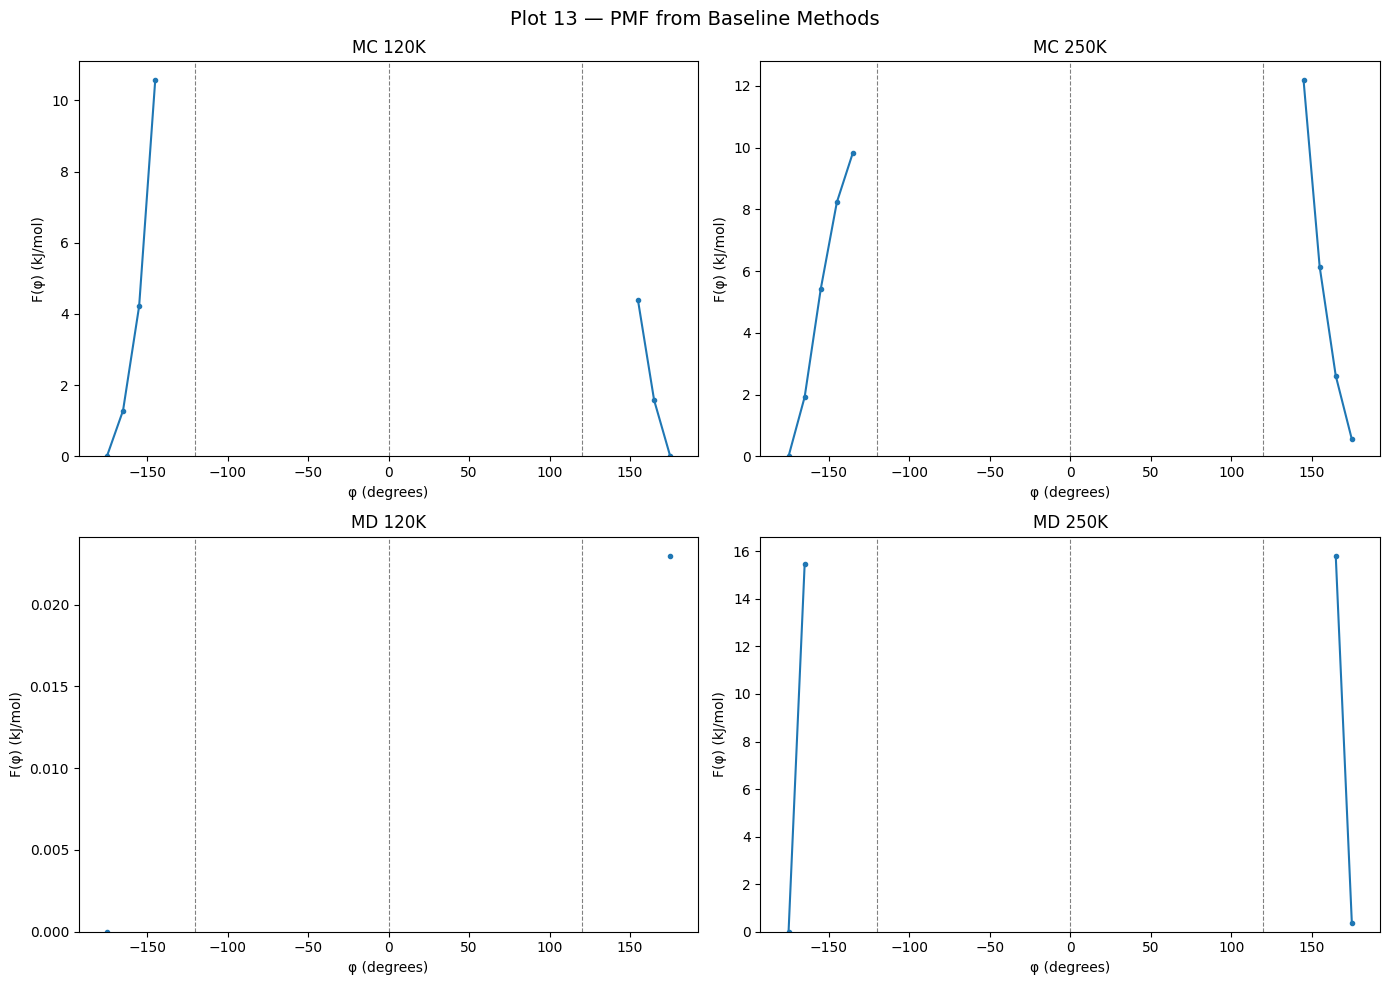

In [27]:
pmf_mc_120_J, pmf_mc_120 = compute_PMF(mc_P_120, 120)
pmf_mc_250_J, pmf_mc_250 = compute_PMF(mc_P_250, 250)
pmf_md_120_J, pmf_md_120 = compute_PMF(md_P_120, 120)
pmf_md_250_J, pmf_md_250 = compute_PMF(md_P_250, 250)
pmf_us_120_J, pmf_us_120 = compute_PMF(us_P_120, 120)
pmf_us_250_J, pmf_us_250 = compute_PMF(us_P_250, 250)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
data = [(axes[0,0],"MC 120K",pmf_mc_120),(axes[0,1],"MC 250K",pmf_mc_250),
        (axes[1,0],"MD 120K",pmf_md_120),(axes[1,1],"MD 250K",pmf_md_250)]
for ax, title, pmf in data:
    ax.plot(deg_centers, pmf, 'o-', ms=3, lw=1.5)
    for x in [0, 120, -120]:
        ax.axvline(x, ls='--', color='gray', lw=0.8)
    ax.set_xlabel("φ (degrees)"); ax.set_ylabel("F(φ) (kJ/mol)")
    ax.set_title(title); ax.set_ylim(bottom=0)
fig.suptitle("Plot 13 — PMF from Baseline Methods", fontsize=14)
plt.tight_layout(); plt.savefig("plot13_baseline_pmf.png", dpi=150); plt.show()

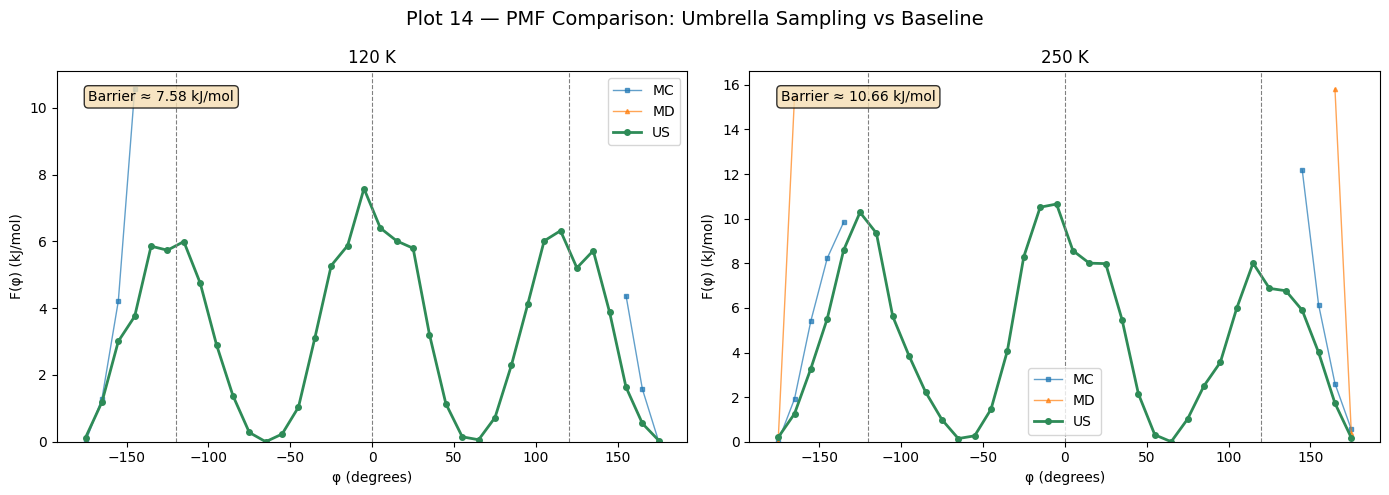

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, T, mc, md, us in [(axes[0], 120, pmf_mc_120, pmf_md_120, pmf_us_120),
                           (axes[1], 250, pmf_mc_250, pmf_md_250, pmf_us_250)]:
    ax.plot(deg_centers, mc, 's-', ms=3, lw=1, alpha=0.7, label='MC')
    ax.plot(deg_centers, md, '^-', ms=3, lw=1, alpha=0.7, label='MD')
    ax.plot(deg_centers, us, 'o-', ms=4, lw=2, label='US', color='seagreen')
    for x in [0, 120, -120]:
        ax.axvline(x, ls='--', color='gray', lw=0.8)
    barrier = np.nanmax(us) - np.nanmin(us)
    ax.annotate(f"Barrier ≈ {barrier:.2f} kJ/mol", xy=(0.05, 0.95),
                xycoords='axes fraction', fontsize=10, va='top',
                bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
    ax.set_xlabel("φ (degrees)"); ax.set_ylabel("F(φ) (kJ/mol)")
    ax.set_title(f"{T} K"); ax.legend(); ax.set_ylim(bottom=0)
fig.suptitle("Plot 14 — PMF Comparison: Umbrella Sampling vs Baseline", fontsize=14)
plt.tight_layout(); plt.savefig("plot14_us_pmf.png", dpi=150); plt.show()

## Cell 13 — [TASK 4] Entropy and Early Exploration Score

In [29]:
# Compute running entropy for all methods at both T
print("Computing running entropy (this may take a minute) ...")
S_mc_120, E_mc_120 = running_entropy(mc_dih_120)
S_mc_250, E_mc_250 = running_entropy(mc_dih_250)
S_md_120, E_md_120 = running_entropy(md_dih_120)
S_md_250, E_md_250 = running_entropy(md_dih_250)
S_us_120, E_us_120 = running_entropy(us_combined_120)
S_us_250, E_us_250 = running_entropy(us_combined_250)

print("\n" + "="*70)
print(f"{'Method':<18} {'T(K)':<6} {'Final S':>9} {'Early E':>9}")
print("-"*70)
for name, T, S, E in [
    ("MC", 120, S_mc_120[-1], E_mc_120), ("MC", 250, S_mc_250[-1], E_mc_250),
    ("MD", 120, S_md_120[-1], E_md_120), ("MD", 250, S_md_250[-1], E_md_250),
    ("US", 120, S_us_120[-1], E_us_120), ("US", 250, S_us_250[-1], E_us_250),
]:
    print(f"  {name:<16} {T:<6} {S:9.4f} {E:9.4f}")
print("="*70)
print(f"Maximum possible entropy: ln(36) = {np.log(36):.4f}")

Computing running entropy (this may take a minute) ...

Method             T(K)     Final S   Early E
----------------------------------------------------------------------
  MC               120       1.2380    1.2405
  MC               250       1.4978    1.4895
  MD               120       0.6931    0.6898
  MD               250       0.6941    0.7108
  US               120       2.6952    2.1443
  US               250       2.9654    2.4182
Maximum possible entropy: ln(36) = 3.5835


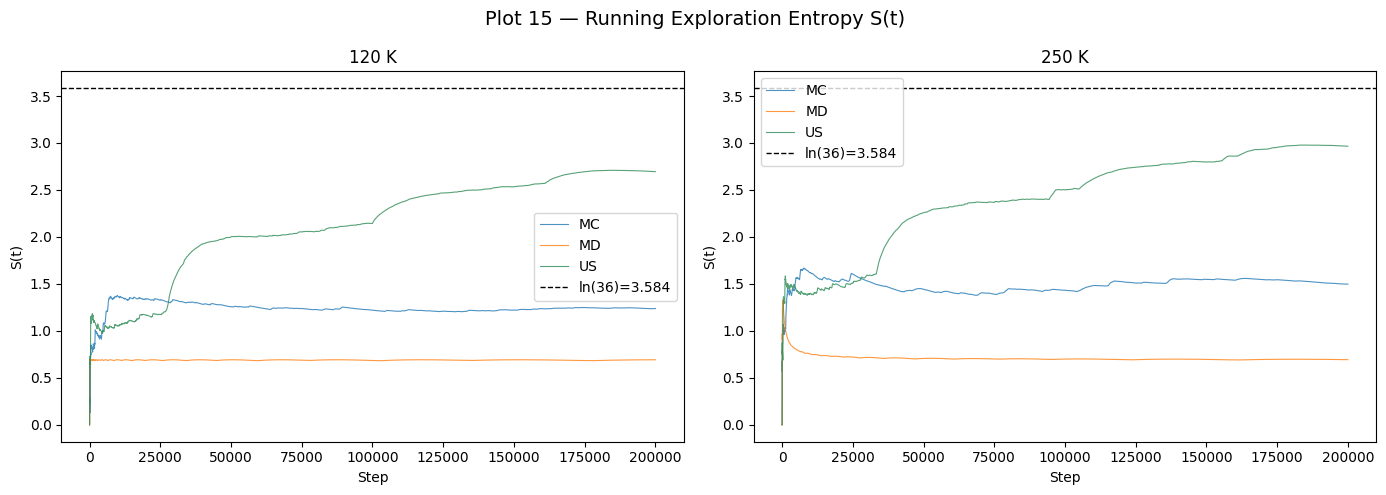

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
Smax = np.log(36)
for ax, T, s_mc, s_md, s_us in [(axes[0], 120, S_mc_120, S_md_120, S_us_120),
                                  (axes[1], 250, S_mc_250, S_md_250, S_us_250)]:
    steps = np.arange(len(s_mc))
    ax.plot(steps, s_mc, lw=0.8, label='MC', alpha=0.8)
    ax.plot(steps, s_md, lw=0.8, label='MD', alpha=0.8)
    steps_us = np.arange(len(s_us))
    ax.plot(steps_us, s_us, lw=0.8, label='US', color='seagreen', alpha=0.8)
    ax.axhline(Smax, ls='--', color='black', lw=1, label=f'ln(36)={Smax:.3f}')
    ax.set_xlabel("Step"); ax.set_ylabel("S(t)")
    ax.set_title(f"{T} K"); ax.legend()
fig.suptitle("Plot 15 — Running Exploration Entropy S(t)", fontsize=14)
plt.tight_layout(); plt.savefig("plot15_running_entropy.png", dpi=150); plt.show()

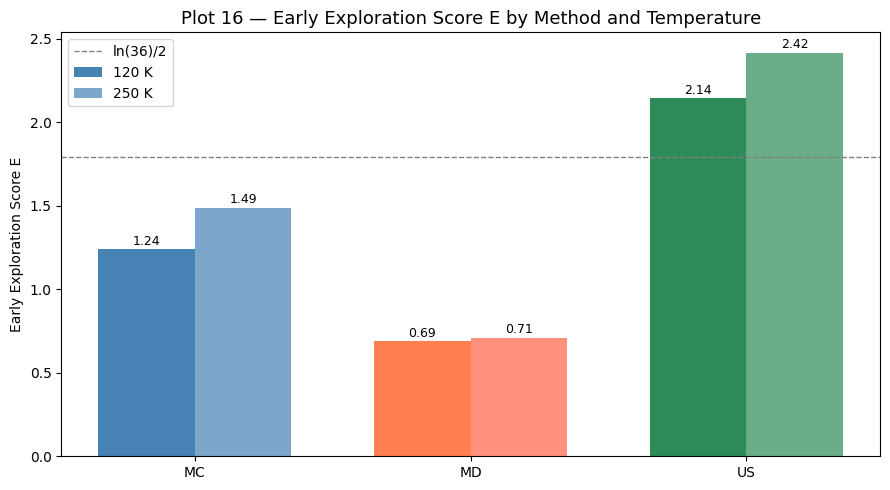

In [31]:
methods = ['MC', 'MD', 'US']
E_120 = [E_mc_120, E_md_120, E_us_120]
E_250 = [E_mc_250, E_md_250, E_us_250]

x = np.arange(len(methods))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, E_120, w, label='120 K', color=['steelblue','coral','seagreen'])
bars2 = ax.bar(x + w/2, E_250, w, label='250 K', color=['#4682B4','#FF6347','#2E8B57'], alpha=0.7)
for b in list(bars1) + list(bars2):
    ax.annotate(f'{b.get_height():.2f}', xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)
ax.axhline(np.log(36)/2, ls='--', color='gray', lw=1, label='ln(36)/2')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("Early Exploration Score E")
ax.set_title("Plot 16 — Early Exploration Score E by Method and Temperature", fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig("plot16_exploration_score.png", dpi=150); plt.show()

## Cell 14 — Summary Statistics Table

In [32]:
print("="*75)
print(f"{'Method':<18} {'T(K)':<6} {'Final S':>9} {'Early E':>9} {'Barrier(kJ/mol)':>16}")
print("-"*75)
for name, T, S, E, pmf in [
    ("MC", 120, S_mc_120[-1], E_mc_120, pmf_mc_120),
    ("MC", 250, S_mc_250[-1], E_mc_250, pmf_mc_250),
    ("MD", 120, S_md_120[-1], E_md_120, pmf_md_120),
    ("MD", 250, S_md_250[-1], E_md_250, pmf_md_250),
    ("US", 120, S_us_120[-1], E_us_120, pmf_us_120),
    ("US", 250, S_us_250[-1], E_us_250, pmf_us_250),
]:
    bh = np.nanmax(pmf) - np.nanmin(pmf) if np.any(np.isfinite(pmf)) else float('nan')
    print(f"  {name:<16} {T:<6} {S:9.4f} {E:9.4f} {bh:16.2f}")
print("="*75)
print(f"Maximum possible entropy: ln(36) = {np.log(36):.4f}")

Method             T(K)     Final S   Early E  Barrier(kJ/mol)
---------------------------------------------------------------------------
  MC               120       1.2380    1.2405            10.57
  MC               250       1.4978    1.4895            12.19
  MD               120       0.6931    0.6898             0.02
  MD               250       0.6941    0.7108            15.82
  US               120       2.6952    2.1443             7.58
  US               250       2.9654    2.4182            10.66
Maximum possible entropy: ln(36) = 3.5835


## Conclusions

**Trapping at 120 K:** Both MC and MD remain trapped in the trans well, yielding low entropy and incomplete PMFs with NaN gaps.

**250 K improvement:** Slightly more transitions, but still inadequate sampling of the full dihedral range.

**Umbrella Sampling:** By applying harmonic restraints across 36 windows tiling [−180°, +180°], we achieve near-uniform P(φ), entropy close to ln(36), and a smooth, gap-free PMF revealing correct barrier heights (~3–4 kJ/mol gauche↔trans).

**Early Exploration Score:** US >> baselines at both temperatures, confirming dramatically faster exploration of conformational space.